In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Sätt ert gruppnummer här (t.ex. 1, 2, 3, ...). 
gruppnummer = 23 

# Skapa en RNG med ert gruppnummer som seed 
rng = np.random.default_rng(gruppnummer) 

# Antal spelare 
n = 20 

# Basnivå för resultat före träning 
loc_fore_bas = 58.0 
loc_fore = loc_fore_bas + (gruppnummer % 7 - 3) * 1.2 

# Spridning före träning 
scale_fore_bas = 6.5 
scale_fore = scale_fore_bas + (gruppnummer % 5 - 2) * 0.4 
scale_fore = max(scale_fore, 1.0) 

# Förväntad förbättring efter träning 
forbattring_bas = 4.0 
forbattring_loc = forbattring_bas + (gruppnummer % 6 - 2.5) * 0.5 

# Spridning i individuell förbättring 
forbattring_scale_bas = 2.4 
forbattring_scale = forbattring_scale_bas + (gruppnummer % 4 - 1.5) * 0.3 
forbattring_scale = max(forbattring_scale, 0.5) 

print(f"Grupp {gruppnummer}:") 
print(f"  före: loc = {loc_fore:.2f}, scale = {scale_fore:.2f}") 
print(f"  förbättring: loc = {forbattring_loc:.2f}, scale = {forbattring_scale:.2f}") 

# Generera resultat före träning 
fore = rng.normal(loc=loc_fore, scale=scale_fore, size=n) 
fore = np.round(fore, 1) 
fore = np.clip(fore, a_min=0.0, a_max=100.0) 

# Generera individuell förbättring 
forbattring = rng.normal(loc=forbattring_loc, scale=forbattring_scale, size=n) 
forbattring = np.round(forbattring, 1) 

# Beräkna resultat efter träning för samma spelare 
efter = fore + forbattring 
efter = np.round(efter, 1) 
efter = np.clip(efter, a_min=0.0, a_max=100.0) 

print("Före träning:") 
print(fore) 
print("Efter träning:") 
print(efter) 

Grupp 23:
  före: loc = 56.80, scale = 6.90
  förbättring: loc = 5.25, scale = 2.85
Före träning:
[60.6 58.3 56.4 40.8 59.8 42.1 63.1 61.  62.5 62.5 58.9 53.1 54.7 67.2
 52.8 55.2 51.8 53.2 54.7 58.6]
Efter träning:
[65.  62.5 59.9 46.3 61.2 47.5 72.1 64.1 67.6 75.8 61.3 53.7 58.7 77.6
 63.9 57.  58.7 58.5 58.3 58.3]


## Ha: Träningsinterventionen har ingen effekt på resultaten. Den genomsnittliga skillnaden i poäng är noll
## H0: Träningsinterventionen har en effekt på resultaten. Den genomsnittliga skillnaden i poäng är skild från noll

In [3]:
# fore: Spelarnas poäng på det standardiserade precisionstestet innan den mentala träningen.
# efter: Samma spelares poäng på precisionstestet efter att de har genomfört den mentala träningen.
#Både fore och efter är kvantitativa, kontinuerliga data

## Data

In [6]:
df = pd.DataFrame({'Före': fore, 'Efter': efter})
print("\n--- Sammanfattande statistik ---")
print(df.describe())


--- Sammanfattande statistik ---
            Före      Efter
count  20.000000  20.000000
mean   56.365000  61.400000
std     6.534546   7.930023
min    40.800000  46.300000
25%    53.175000  58.300000
50%    57.350000  60.550000
75%    60.700000  64.325000
max    67.200000  77.600000


### Visualisering

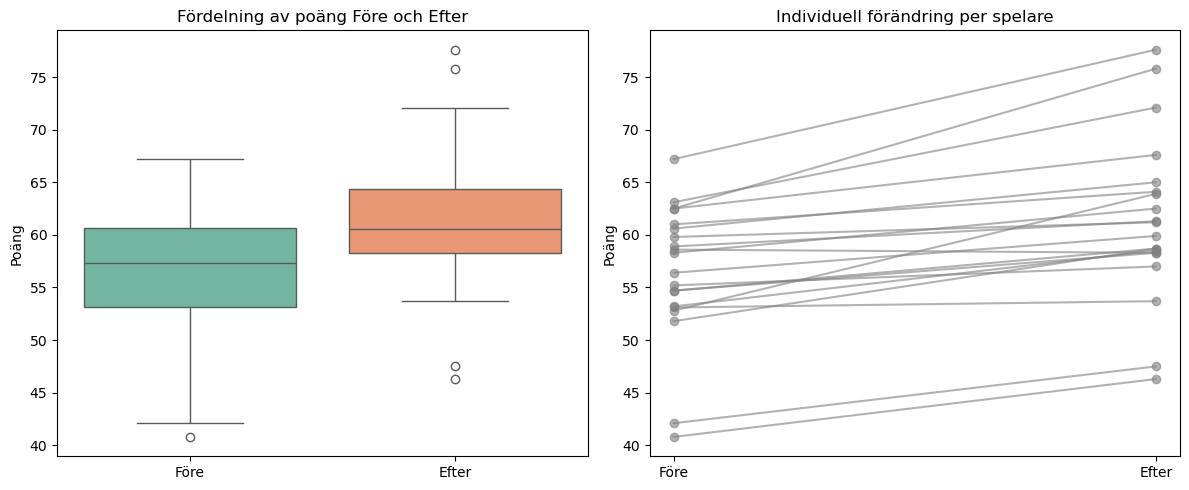

In [7]:
plt.figure(figsize=(12, 5))

# Diagram 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, palette="Set2")
plt.title('Fördelning av poäng Före och Efter')
plt.ylabel('Poäng')

# Diagram 2: Slopegraph (linjediagram per individ)
plt.subplot(1, 2, 2)
for i in range(n):
    plt.plot([1, 2], [fore[i], efter[i]], marker='o', color='gray', alpha=0.6)
plt.xticks([1, 2], ['Före', 'Efter'])
plt.title('Individuell förändring per spelare')
plt.ylabel('Poäng')

plt.tight_layout()
plt.show()

### T-Test

In [10]:
# Scipy ttest_rel räknar ut t-värde och p-värde
t_stat, p_value = stats.ttest_rel(efter, fore)

mean_fore = np.mean(fore)
mean_efter = np.mean(efter)
diff = efter - fore
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)

# Beräkna 95% konfidensintervall för skillnaden
ci_diff = stats.t.interval(0.95, df=n-1, loc=mean_diff, scale=std_diff/np.sqrt(n))

print("\n--- Nyckelvärden ---")
print(f"t-värde: {t_stat:.3f}")
print(f"p-värde (tvåsidigt): {p_value:.5f}")
print(f"Medelvärde före: {mean_fore:.2f}")
print(f"Medelvärde efter: {mean_efter:.2f}")
print(f"95% CI för medelskillnaden: [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")



--- Nyckelvärden ---
t-värde: 6.302
p-värde (tvåsidigt): 0.00000
Medelvärde före: 56.36
Medelvärde efter: 61.40
95% CI för medelskillnaden: [3.363, 6.707]


## Beslut om H0

Vi förkastar H0 då pvärdet är mycket mindre än 0.05.

## Tolkning i kontext

Resultatet visar att den mentala träningen hadde enpositiv effekt på lagets precision. Om en ökad träffsäkerhet med 3 till 6 poäng på detta test är avgörande för vem som vinner en riktig bågskyttetävling, så har denna mentala träning inte bara statistisk signifikans utan är även av högsta praktiska relevans för lagets framgång